# 🧪 실험 3 (v4 Final): 2단계 전이학습 + EDA 개선 + HDD 최적화

---

## 🔥 v4에서 추가된 점 (v3 → v4)

상대방 코드의 **2단계 전이학습(backbone 미세조정)**을 우리 v3에 합쳤습니다.

| # | 전략 | v3 (이전) | v4 (최종) | 효과 |
|---|------|-----------|-----------|------|
| 🔥 | **학습 전략** | 1단계 (헤드만) | **2단계 (헤드 → backbone 미세조정)** | 정확도 5~15%p 향상 |
| ⚡ | **Mixed Precision** | float32 | **AMP (float16/32 혼합)** | 학습 속도 1.5~2배 |
| 📦 | **앱 연동** | 없음 | **metrics.json 자동 저장** | Streamlit 즉시 연결 |

### v3에서 이미 적용된 것 (유지)
- ① **letterbox**: 16:9 종횡비 보존 (병변 왜곡 방지)
- ② **종 기준 가중**: 반려묘 손실 ~2배 가중
- ③ **CYT 제외**: 일반카메라(IMG)만
- ⚡ **numpy RAM 캐싱**: HDD 디스크 병목 차단
- 📉 과적합 대책: Dropout 0.5, EarlyStopping, ReduceLR

### 2단계 학습 전략
```
[Stage 1] 헤드 워밍업 (backbone 동결)
  LR = 1e-3  |  max 10 에폭  |  분류 헤드만 학습 → 빠른 수렴
                    ↓
[Stage 2] 전체 미세조정 (backbone 해동)
  LR = 1e-5  |  max 20 에폭  |  피부질환 특화 특징 학습 → 정확도 핵심
```

> ⚠️ **EDA 사실**: 반려묘는 A2·A4·A6·A7 4개 클래스에만 존재 (A1·A3·A5는 0장)

---

## 0. 라이브러리 임포트 및 설정

실험 2와 동일합니다. 추가로 **class_weight 계산을 위한 sklearn** 유틸리티를 임포트합니다.


In [22]:
!pip install torch

In [23]:
import sys
print(f"Python: {sys.executable}")

import torch
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA 버전: {torch.version.cuda}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM: {total_mem:.1f} GB")
    device = torch.device("cuda")
else:
    print("GPU 없음 — CPU로 실행")
    device = torch.device("cpu")

print(f"사용 디바이스: {device}")


Python: d:\anaconda\envs\tf_gpu\python.exe
PyTorch 버전: 2.5.1+cu121
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 2070 SUPER
CUDA 버전: 12.1
VRAM: 8.0 GB
사용 디바이스: cuda


In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.models as models
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"PyTorch    : {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"디바이스   : {device}")


PyTorch    : 2.5.1+cu121
torchvision: 0.20.1+cu121
디바이스   : cuda


## 1. 경로 설정 및 데이터 로딩

실험 1, 2와 **동일한 데이터, 동일한 분할**을 사용합니다.  
실험 간 공정한 비교를 위해 데이터는 절대 바꾸지 않습니다.


In [25]:
ROOT      = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
FIG_DIR   = ROOT / 'outputs' / 'figures'
MODEL_DIR = ROOT / 'models'

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# CSV 로딩
df = pd.read_csv(PROCESSED / 'dataset_cleaned.csv')
target_col = 'img_path'

# ── ③ v3 개선: 현미경(CYT) 이미지 제외, 일반카메라(IMG)만 사용 ──
# CYT는 2048x1644·밝기 188로 일반카메라(1920x1080·밝기 135)와 분포가 완전히 다름
# 파일명 접두사로 구분: IMG_* (일반카메라) vs CYT_* (현미경)
before = len(df)
df = df[df['img_file'].str.startswith('IMG')].copy()
removed = before - len(df)
print(f"③ CYT(현미경) 제외: {removed:,}장 제거 → {len(df):,}장 유지\n")

df_train = df[df['split'] == 'train'].copy()
df_val   = df[df['split'] == 'val'].copy()
df_test  = df[df['split'] == 'test'].copy()

print(f"✅ 데이터 로드 완료 (IMG 일반카메라만)")
print(f"  train : {len(df_train):,}장")
print(f"  val   : {len(df_val):,}장")
print(f"  test  : {len(df_test):,}장")

# 종별 분포 확인 (EDA 기반 — 반려묘는 A2/A4/A6/A7에만 존재)
print(f"\n  [종별 분포]")
for sp in ['D', 'C']:
    label = '반려견' if sp == 'D' else '반려묘'
    cnt = len(df_train[df_train['species'] == sp])
    print(f"    {sp}({label}): {cnt:,}장")

③ CYT(현미경) 제외: 0장 제거 → 34,987장 유지

✅ 데이터 로드 완료 (IMG 일반카메라만)
  train : 24,492장
  val   : 5,249장
  test  : 5,246장

  [종별 분포]
    D(반려견): 21,736장
    C(반려묘): 2,756장


## 2. 하이퍼파라미터 설정

실험 2와 동일합니다. Class Weight는 별도 단계에서 계산합니다.


In [26]:
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 64           # ⚡ VRAM 8GB에 안전
NUM_CLASSES   = 7

# ── 2단계 학습 하이퍼파라미터 ──
EPOCHS_HEAD   = 15           # Stage 1: 헤드 워밍업 (backbone 동결)
EPOCHS_FT     = 40           # Stage 2: 전체 미세조정 (backbone 해동)
LR_HEAD       = 1e-3         # Stage 1: 큰 LR로 헤드 빠르게 수렴
LR_FT         = 2e-5         # Stage 2: 작은 LR로 backbone 조심스럽게 조정

DROPOUT       = 0.5          # 📉 과적합 방어 (v3 유지)

print(f"이미지 크기    : {IMG_SIZE}")
print(f"배치 크기      : {BATCH_SIZE}")
print(f"Stage 1 (헤드) : {EPOCHS_HEAD}에폭, LR={LR_HEAD}")
print(f"Stage 2 (미세) : {EPOCHS_FT}에폭, LR={LR_FT}")
print(f"Dropout        : {DROPOUT}")

이미지 크기    : (224, 224)
배치 크기      : 64
Stage 1 (헤드) : 15에폭, LR=0.001
Stage 2 (미세) : 40에폭, LR=2e-05
Dropout        : 0.5


## 3. 가중치 계산 (v3: 종 기준 sample_weight)

> 🔄 **v3 변경**: 아래 표는 원본(v2) 설명입니다. v3에서는 질환 class_weight 대신 **종(species) 기준 sample_weight**를 학습에 사용합니다 (질환은 균형이라 효과가 없었기 때문).

### (원본 설명) Class Weight 계산 ⭐ (실험 3 핵심)

이 단계가 **실험 2와의 유일한 차이점**입니다.

### 실험 3에서 적용하는 가중치

| 가중치 | 기준 | 적용 방식 | 목적 |
|--------|------|----------|------|
| **class_weight** | 질환별 (A1~A7) | `model.fit(class_weight=...)` | 질환 클래스 불균형 보정 ✅ |
| species_weight | 종별 (반려견/반려묘) | 참고용 (학습 미적용) | 불균형 규모 파악 |

> 💡 종별 불균형(`species_weight`)은 데이터 현황 파악을 위해 계산하되, 학습에는 적용하지 않습니다.  
> 종별 불균형까지 보정하려면 `sample_weight`로 결합 가중치를 적용할 수 있으나, 실험 3에서는 질환별 `class_weight`만 사용합니다.

### sample_weight vs class_weight 차이

- `class_weight`: **클래스 단위** 가중치. A1이 적으면 A1 전체에 높은 가중치
- `sample_weight`: **샘플(이미지) 단위** 가중치. 같은 A1이라도 반려묘면 가중치가 더 높음

In [27]:
# ── ② v3 개선: 종(species) 가중치를 sample_weight로 학습에 실제 적용 ──
# EDA 발견: 질환(lesion)은 거의 균형 → lesion 기준 class_weight는 효과 미미
# 진짜 불균형은 종(반려견 88.6% vs 반려묘 11.4%)이므로 종 기준으로 가중

species_classes = np.array(sorted(df_train['species'].unique()))
species_weights = compute_class_weight(
    class_weight='balanced',
    classes=species_classes,
    y=df_train['species']
)
species_weight_map = dict(zip(species_classes, species_weights))  # {'C': ~3.x, 'D': ~0.5x}

print("=== 종별(species) 가중치 (v3: 학습에 실제 적용) ===")
for k, v in species_weight_map.items():
    label = '반려묘' if k == 'C' else '반려견'
    count = len(df_train[df_train['species'] == k])
    print(f"  {k} ({label}): {v:.3f}  (데이터 {count:,}장)")
print("\n  → 이 가중치로 각 샘플의 sample_weight를 만들어 model.fit에 전달합니다.")

=== 종별(species) 가중치 (v3: 학습에 실제 적용) ===
  C (반려묘): 4.443  (데이터 2,756장)
  D (반려견): 0.563  (데이터 21,736장)

  → 이 가중치로 각 샘플의 sample_weight를 만들어 model.fit에 전달합니다.


In [28]:
# ── 3-2. 질환별(lesion) 클래스 가중치 계산 ──
# Generator의 class_indices 순서에 의존하지 않도록 이름→가중치 맵으로 저장
# class_weight_dict는 Generator 생성 후 class_indices를 참조하여 확정 (Section 4)

lesion_classes = sorted(df_train['lesion'].unique())
lesion_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(lesion_classes),
    y=df_train['lesion']
)
lesion_weight_map = dict(zip(lesion_classes, lesion_weights))  # {클래스명: 가중치}

print("=== 질환별(lesion) 클래스 가중치 ===")
for cls, w in lesion_weight_map.items():
    count = len(df_train[df_train['lesion'] == cls])
    print(f"  {cls} → 가중치 {w:.3f}  (데이터 {count:,}장)")

=== 질환별(lesion) 클래스 가중치 ===
  A1 → 가중치 1.000  (데이터 3,499장)
  A2 → 가중치 1.000  (데이터 3,499장)
  A3 → 가중치 1.000  (데이터 3,498장)
  A4 → 가중치 1.001  (데이터 3,497장)
  A5 → 가중치 1.000  (데이터 3,500장)
  A6 → 가중치 1.000  (데이터 3,499장)
  A7 → 가중치 1.000  (데이터 3,500장)


## 4. 데이터 Generator 생성 (증강 적용)

실험 2와 **동일한 증강 설정**입니다.  
Class Weight는 Generator가 아니라 **model.fit()에서 적용**합니다.


In [29]:
# ① LetterboxResize: 16:9 종횡비 보존 (TF resize_with_pad 동일 효과)
class LetterboxResize:
    def __init__(self, size):
        self.size = size  # (H, W)

    def __call__(self, img):
        w, h = img.size
        scale   = min(self.size[0] / h, self.size[1] / w)
        new_h   = int(h * scale)
        new_w   = int(w * scale)
        img     = TF.resize(img, [new_h, new_w])
        pad_t   = (self.size[0] - new_h) // 2
        pad_b   = self.size[0] - new_h - pad_t
        pad_l   = (self.size[1] - new_w) // 2
        pad_r   = self.size[1] - new_w - pad_l
        img     = TF.pad(img, [pad_l, pad_t, pad_r, pad_b], fill=0)
        return img

# EfficientNetB0 사전학습 통계 (ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ⚡ [최종 최적화] letterbox는 랜덤 요소가 없으므로 캐싱 단계에서 미리 적용.
#    데이터가 HDD(D드라이브)에 있어 디스크 I/O가 병목 → 224 uint8 배열을 RAM에 캐싱.
#    캐시 후 transform은 '증강+정규화'만 수행 (letterbox 재연산 불필요).
_letterbox = LetterboxResize(IMG_SIZE)

# Train: 증강 O (캐시된 224 배열에 적용)
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Val/Test: 증강 X
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# PyTorch Dataset — ⚡ numpy RAM 캐싱 버전
class SkinDataset(Dataset):
    def __init__(self, paths, labels, weights=None, transform=None, cache_name=""):
        self.paths     = paths
        self.labels    = labels
        self.weights   = weights
        self.transform = transform

        # ⚡ [최종] 최초 1회: letterbox(224) 적용한 uint8 numpy 배열을 RAM에 캐싱.
        #    이후 에폭부터는 HDD 접근 0 → 디스크 병목 원천 차단.
        #    메모리: 224x224x3 = 147KB/장. 35,000장 ≈ 5.3GB (시스템 RAM 32GB면 여유).
        print(f"  [{cache_name}] letterbox 224 캐싱 중... ({len(paths):,}장)")
        self.images = [
            np.asarray(_letterbox(Image.open(p).convert("RGB")), dtype=np.uint8)
            for p in paths
        ]
        print(f"  [{cache_name}] 캐싱 완료 (RAM 상주, 디스크 I/O 차단)")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # 캐시된 224 배열 → PIL → 증강+정규화 (디스크 접근 없음)
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.weights is not None:
            return img, label, torch.tensor(self.weights[idx], dtype=torch.float32)
        return img, label

print("Dataset / Transforms 정의 완료 (⚡ numpy RAM 캐싱)")
print("  ① LetterboxResize: 캐싱 단계에서 사전 적용 (16:9 종횡비 보존)")
print("  ② ImageNet 정규화 (EfficientNetB0 사전학습 통계)")
print("  ⚡ HDD 병목 차단: 224 uint8 배열을 RAM에 상주")

Dataset / Transforms 정의 완료 (⚡ numpy RAM 캐싱)
  ① LetterboxResize: 캐싱 단계에서 사전 적용 (16:9 종횡비 보존)
  ② ImageNet 정규화 (EfficientNetB0 사전학습 통계)
  ⚡ HDD 병목 차단: 224 uint8 배열을 RAM에 상주


In [30]:
lesion_to_idx = {cls: i for i, cls in enumerate(lesion_classes)}
idx_to_lesion = {i: cls for cls, i in lesion_to_idx.items()}
print("클래스 인덱스:", lesion_to_idx)

def df_to_arrays(d, with_weight=False):
    paths   = d[target_col].values
    labels  = np.array([lesion_to_idx[l] for l in d["lesion"].values], dtype=np.int64)
    if with_weight:
        weights = np.array([species_weight_map[s] for s in d["species"].values], dtype=np.float32)
        return paths, labels, weights
    return paths, labels

train_paths, train_labels, train_weights = df_to_arrays(df_train, with_weight=True)
val_paths,   val_labels                  = df_to_arrays(df_val)
test_paths,  test_labels                 = df_to_arrays(df_test)

print(f"\ntrain: {len(train_paths):,} / val: {len(val_paths):,} / test: {len(test_paths):,}")
print(f"  ② 종 sample_weight — 반려묘: {species_weight_map['C']:.3f}, 반려견: {species_weight_map['D']:.3f}")


클래스 인덱스: {'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'A6': 5, 'A7': 6}

train: 24,492 / val: 5,249 / test: 5,246
  ② 종 sample_weight — 반려묘: 4.443, 반려견: 0.563


## 4-1. PyTorch DataLoader 구성

SkinDataset + DataLoader로 파이프라인을 구성합니다:

- **Train**: `(img, label, sample_weight)` 3-튜플, 증강 O
- **Val/Test**: `(img, label)` 2-튜플, 증강 X
- `pin_memory=True`: CPU→GPU 전송 속도 향상
- `num_workers=0`: Windows Jupyter 호환 (필요시 2~4로 늘릴 수 있음)


In [31]:
# ⚡ 최초 생성 시 letterbox 캐싱 진행 (HDD에서 1회 읽기, 몇 분 소요될 수 있음)
print("\n--- [데이터셋 RAM 캐싱 시작] (최초 1회만 대기, 이후 에폭 초고속) ---")
train_ds = SkinDataset(train_paths, train_labels, weights=train_weights,
                       transform=train_transform, cache_name="train")
val_ds   = SkinDataset(val_paths,   val_labels,
                       transform=eval_transform, cache_name="val")
test_ds  = SkinDataset(test_paths,  test_labels,
                       transform=eval_transform, cache_name="test")

# num_workers=0: 캐싱으로 디스크 I/O가 없어 worker 불필요 + Windows Jupyter spawn 이슈 회피
# pin_memory=True: RAM→GPU 전송 대역폭 최적화
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print("\nDataLoader 구성 완료 (배치 64, RAM 캐싱)")
print(f"  train: {len(train_ds):,}장, {len(train_loader)}배치")
print(f"  val  : {len(val_ds):,}장,  {len(val_loader)}배치")
print(f"  test : {len(test_ds):,}장,  {len(test_loader)}배치")


--- [데이터셋 RAM 캐싱 시작] (최초 1회만 대기, 이후 에폭 초고속) ---
  [train] letterbox 224 캐싱 중... (24,492장)
  [train] 캐싱 완료 (RAM 상주, 디스크 I/O 차단)
  [val] letterbox 224 캐싱 중... (5,249장)
  [val] 캐싱 완료 (RAM 상주, 디스크 I/O 차단)
  [test] letterbox 224 캐싱 중... (5,246장)
  [test] 캐싱 완료 (RAM 상주, 디스크 I/O 차단)

DataLoader 구성 완료 (배치 64, RAM 캐싱)
  train: 24,492장, 383배치
  val  : 5,249장,  83배치
  test : 5,246장,  82배치


## 5. EfficientNetB0 + 커스텀 분류층 정의 (PyTorch)

```
입력 (224×224×3)
    ↓
EfficientNetB0.features (ImageNet 사전학습, freeze)
    ↓
AdaptiveAvgPool2d → 1280
    ↓
Dropout(0.5) → Linear(1280→256) → ReLU → Dropout(0.5)
    ↓
Linear(256→7) → [A1~A7 로짓]
```


In [32]:
import ssl

# SSL 인증서 검증 비활성화
ssl._create_default_https_context = ssl._create_unverified_context

# 그 다음 기존 코드 실행
from torchvision import models

backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
print("🎉 EfficientNetB0 가중치 다운로드 성공!")

🎉 EfficientNetB0 가중치 다운로드 성공!


In [33]:
# EfficientNetB0 사전학습 가중치 로드
backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# [Stage 1] 특징 추출부 동결 → 분류 헤드만 학습
for param in backbone.features.parameters():
    param.requires_grad = False

# 분류 헤드 교체 (1280 → 256 → 7)
backbone.classifier = nn.Sequential(
    nn.Linear(1280, 256),
    nn.ReLU(),
    nn.Dropout(DROPOUT),
    nn.Linear(256, NUM_CLASSES),
)
model = backbone.to(device)

# ⚡ AMP (Automatic Mixed Precision) — GPU float16 연산으로 속도 1.5~2배 향상
use_amp = device.type == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("EfficientNetB0 모델 구성 완료 (Stage 1: backbone 동결)")
print(f"  전체 파라미터     : {total_p:,}")
print(f"  학습 가능 파라미터 : {trainable_p:,}  (분류 헤드만)")
print(f"  AMP 혼합정밀도    : {'✅ 활성' if use_amp else '❌ CPU (비활성)'}")

EfficientNetB0 모델 구성 완료 (Stage 1: backbone 동결)
  전체 파라미터     : 4,337,283
  학습 가능 파라미터 : 329,735  (분류 헤드만)
  AMP 혼합정밀도    : ✅ 활성


## 6. 옵티마이저 / 손실함수 / 스케줄러 설정

- **Optimizer**: Adam (학습 가능 파라미터만)
- **Loss**: `CrossEntropyLoss(reduction="none")` → sample_weight를 직접 곱한 뒤 `.mean()`
- **Scheduler**: `ReduceLROnPlateau(factor=0.3, patience=2)`


In [34]:
# ── Stage 1 옵티마이저 (헤드만, 큰 LR) ──
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD
)

# reduction="none": sample_weight를 배치 단위로 곱하기 위해
criterion = nn.CrossEntropyLoss(reduction="none")

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.3, patience=8, min_lr=1e-7
)

print("Stage 1 학습 설정 완료")
print(f"  Optimizer : Adam(lr={LR_HEAD})")
print(f"  Loss      : CrossEntropyLoss (reduction=none, sample_weight 적용)")
print(f"  Scheduler : ReduceLROnPlateau(factor=0.3, patience=2)")

Stage 1 학습 설정 완료
  Optimizer : Adam(lr=0.001)
  Loss      : CrossEntropyLoss (reduction=none, sample_weight 적용)
  Scheduler : ReduceLROnPlateau(factor=0.3, patience=2)


## 7. 학습 설정 (EarlyStopping / ModelCheckpoint)

TF Callback 대신 학습 루프 안에서 직접 구현합니다.

| 기능 | 설정 |
|------|------|
| EarlyStopping | patience=3, val_loss 기준 |
| ModelCheckpoint | val_loss 최저 시 `.pt` 저장 |
| ReduceLROnPlateau | 이미 scheduler에 설정됨 |


In [35]:
save_path       = MODEL_DIR / "exp3_v4_final.pt"
best_val_loss   = float("inf")
patience_counter = 0
PATIENCE        = 3
history = {"loss": [], "acc": [], "val_loss": [], "val_acc": [], "lr": [], "stage": []}

print(f"모델 저장 경로 : {save_path}")
print(f"EarlyStopping  : patience={PATIENCE}")

모델 저장 경로 : ..\models\exp3_v4_final.pt
EarlyStopping  : patience=3


## 8. 🔥 2단계 학습 (Stage 1: 헤드 워밍업 → Stage 2: backbone 미세조정)

**Stage 1**: backbone 동결, 분류 헤드만 LR=1e-3으로 빠르게 학습 (최대 10에폭)
**Stage 2**: backbone 해동, 전체 모델을 LR=1e-5로 피부질환 특화 미세조정 (최대 20에폭)

이것이 정확도에 가장 큰 영향을 주는 핵심 전략입니다.

In [36]:
def run_epoch(loader, is_train=True):
    """1에폭 학습/검증. AMP + 종 sample_weight 적용."""
    model.train() if is_train else model.eval()
    total_loss = total_correct = total_samples = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            if len(batch) == 3:
                imgs, labels, sample_w = batch
                sample_w = sample_w.to(device)
            else:
                imgs, labels = batch[0], batch[1]
                sample_w = None

            imgs   = imgs.to(device)
            labels = labels.to(device)

            if is_train:
                optimizer.zero_grad()

            # ⚡ AMP: forward pass를 float16으로 실행 (GPU에서만 활성)
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                loss_per_sample = criterion(outputs, labels)
                loss = (loss_per_sample * sample_w).mean() if sample_w is not None \
                       else loss_per_sample.mean()

            if is_train:
                scaler.scale(loss).backward()       # ⚡ AMP: scaled backward
                scaler.step(optimizer)               # ⚡ AMP: unscale + step
                scaler.update()                      # ⚡ AMP: scale factor 업데이트

            total_loss    += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += imgs.size(0)

    return total_loss / total_samples, total_correct / total_samples


def train_stage(stage_name, max_epochs, patience_limit):
    """한 단계의 학습 루프 (EarlyStopping + Checkpoint + ReduceLR)."""
    global best_val_loss, patience_counter
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_epoch(train_loader, is_train=True)
        val_loss,   val_acc   = run_epoch(val_loader,   is_train=False)

        current_lr = optimizer.param_groups[0]["lr"]
        history["loss"].append(train_loss)
        history["acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)
        history["stage"].append(stage_name)

        print(f"[{stage_name}] Epoch {epoch:2d}/{max_epochs}  "
              f"loss={train_loss:.4f}  acc={train_acc:.4f}  "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
              f"lr={current_lr:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"  -> 최적 모델 저장 (val_loss={val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  -> 개선 없음 ({patience_counter}/{patience_limit})")

        scheduler.step(val_loss)

        if patience_counter >= patience_limit:
            print(f"  EarlyStopping: {patience_limit}에폭 개선 없어 {stage_name} 종료")
            break

    # 최적 가중치 복원
    model.load_state_dict(torch.load(save_path, weights_only=True, map_location=device))
    print(f"\n{stage_name} 완료! best val_loss={best_val_loss:.4f}")


# ============================================================
# Stage 1: 헤드 워밍업 (backbone 동결, LR=1e-3)
# ============================================================
print("=" * 60)
print("🚀 Stage 1: 헤드 워밍업 (backbone 동결, LR=1e-3)")
print("=" * 60)
print(f"  ① LetterboxResize — 16:9 종횡비 보존")
print(f"  ② 종 sample_weight — 반려묘 {species_weight_map['C']:.2f} / 반려견 {species_weight_map['D']:.2f}")
print(f"  ③ CYT 현미경 제외 (IMG만)")
print(f"  ⚡ AMP 혼합정밀도: {'활성' if use_amp else '비활성'}")
print()

train_stage("Stage1", EPOCHS_HEAD, patience_limit=3)

# ============================================================
# Stage 2: 전체 미세조정 (backbone 해동, LR=1e-5) ⭐ 정확도 핵심
# ============================================================
print("\n" + "=" * 60)
print("🔥 Stage 2: backbone 미세조정 (전체 해동, LR=1e-5)")
print("=" * 60)

# backbone 해동 → 전체 모델 학습 가능
for param in model.features.parameters():
    param.requires_grad = True

trainable_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  학습 가능 파라미터: {trainable_ft:,} (전체 모델)")

# Stage 2 옵티마이저 (작은 LR + 새로운 scheduler)
optimizer = optim.Adam(model.parameters(), lr=LR_FT)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.3, patience=2, min_lr=1e-7
)
print(f"  Optimizer: Adam(lr={LR_FT})")
print()

train_stage("Stage2", EPOCHS_FT, patience_limit=4)

total_epochs = len(history["loss"])
print(f"\n🎉 2단계 학습 완료! 총 {total_epochs}에폭, best val_loss={best_val_loss:.4f}")
print(f"   저장 경로: {save_path}")

🚀 Stage 1: 헤드 워밍업 (backbone 동결, LR=1e-3)
  ① LetterboxResize — 16:9 종횡비 보존
  ② 종 sample_weight — 반려묘 4.44 / 반려견 0.56
  ③ CYT 현미경 제외 (IMG만)
  ⚡ AMP 혼합정밀도: 활성

[Stage1] Epoch  1/15  loss=1.6674  acc=0.2257  val_loss=1.8020  val_acc=0.2860  lr=1.00e-03
  -> 최적 모델 저장 (val_loss=1.8020)
[Stage1] Epoch  2/15  loss=1.5508  acc=0.2734  val_loss=1.7824  val_acc=0.2953  lr=1.00e-03
  -> 최적 모델 저장 (val_loss=1.7824)
[Stage1] Epoch  3/15  loss=1.4958  acc=0.2940  val_loss=1.7153  val_acc=0.3265  lr=1.00e-03
  -> 최적 모델 저장 (val_loss=1.7153)
[Stage1] Epoch  4/15  loss=1.4529  acc=0.3066  val_loss=1.6967  val_acc=0.3351  lr=1.00e-03
  -> 최적 모델 저장 (val_loss=1.6967)
[Stage1] Epoch  5/15  loss=1.4159  acc=0.3194  val_loss=1.6869  val_acc=0.3328  lr=1.00e-03
  -> 최적 모델 저장 (val_loss=1.6869)
[Stage1] Epoch  6/15  loss=1.3829  acc=0.3318  val_loss=1.6601  val_acc=0.3519  lr=1.00e-03
  -> 최적 모델 저장 (val_loss=1.6601)
[Stage1] Epoch  7/15  loss=1.3547  acc=0.3404  val_loss=1.6542  val_acc=0.3578  lr=1.00e-03
  -> 최

KeyboardInterrupt: 

## 9. 학습 곡선 시각화

실험 2와 비교하여 **Val Loss/Accuracy가 어떻게 달라졌는지** 확인합니다.


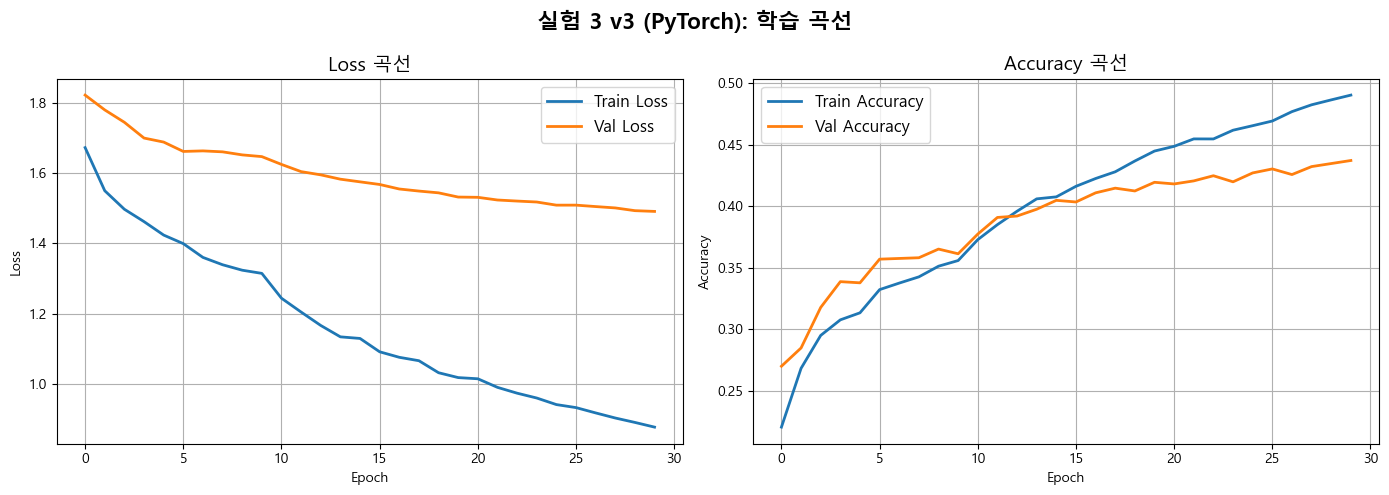

학습 곡선 저장 -> ..\outputs\figures\exp3_v3_learning_curve.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["loss"],     label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss",   linewidth=2)
axes[0].set_title("Loss 곡선", fontsize=14)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=12); axes[0].grid(True)

axes[1].plot(history["acc"],     label="Train Accuracy", linewidth=2)
axes[1].plot(history["val_acc"], label="Val Accuracy",   linewidth=2)
axes[1].set_title("Accuracy 곡선", fontsize=14)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=12); axes[1].grid(True)

plt.suptitle("실험 3 v3 (PyTorch): 학습 곡선", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "exp3_v3_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"학습 곡선 저장 -> {FIG_DIR / 'exp3_v3_learning_curve.png'}")


## 10. 테스트 데이터 평가


In [ ]:
print("=" * 50)
print("테스트 데이터 평가")
print("=" * 50)

model.eval()
total_loss_sum = total_correct = total_samples = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels).mean()
        total_loss_sum += loss.item() * imgs.size(0)
        total_correct  += (outputs.argmax(1) == labels).sum().item()
        total_samples  += imgs.size(0)

test_loss = total_loss_sum / total_samples
test_acc  = total_correct  / total_samples

print(f"\n테스트 Loss    : {test_loss:.4f}")
print(f"테스트 Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")


테스트 데이터 평가

테스트 Loss    : 1.5155
테스트 Accuracy: 0.4318 (43.2%)


## 11. 상세 평가 — Classification Report

실험 2 대비 **반려묘 관련 클래스의 Recall/F1이 올랐는지** 확인하는 것이 핵심입니다.


In [ ]:
model.eval()
all_preds, all_labels_list = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels_list.extend(labels.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels_list)

class_names = [idx_to_lesion[i] for i in range(NUM_CLASSES)]
LESION_MAP = {
    "A1": "A1 구진/플라크", "A2": "A2 비듬/각질", "A3": "A3 태선화/색소",
    "A4": "A4 농포/여드름", "A5": "A5 미란/궤양", "A6": "A6 결절/종괴",
    "A7": "A7 무증상(정상)"
}
class_labels = [LESION_MAP[c] for c in class_names]

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))


=== Classification Report ===
              precision    recall  f1-score   support

   A1 구진/플라크       0.35      0.34      0.35       749
    A2 비듬/각질       0.35      0.35      0.35       750
   A3 태선화/색소       0.36      0.46      0.40       750
   A4 농포/여드름       0.42      0.37      0.39       749
    A5 미란/궤양       0.60      0.51      0.55       750
    A6 결절/종괴       0.55      0.56      0.56       750
  A7 무증상(정상)       0.44      0.43      0.44       748

    accuracy                           0.43      5246
   macro avg       0.44      0.43      0.43      5246
weighted avg       0.44      0.43      0.43      5246



### 11-1. Confusion Matrix (혼동 행렬)

실험 2 대비 **대각선 값이 더 고르게 분포**하는지 확인하세요.  
특정 클래스만 잘 맞추는 게 아니라, 모든 클래스를 공평하게 맞추는 것이 목표입니다.


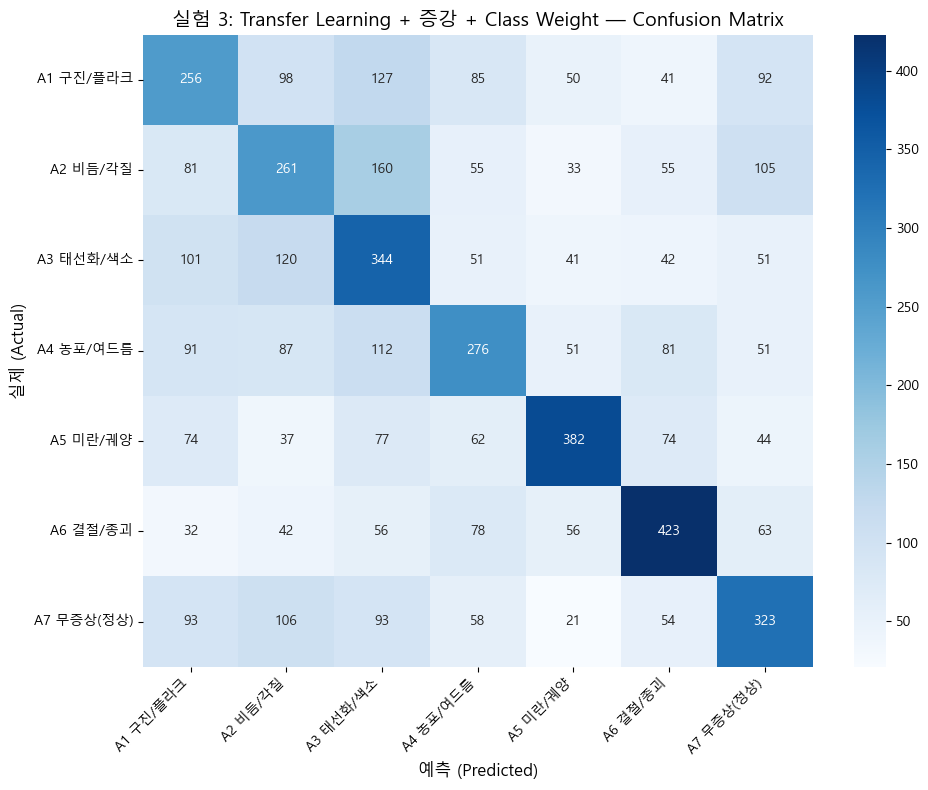

📊 혼동 행렬 저장 → ..\outputs\figures\exp3_confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_xlabel('예측 (Predicted)', fontsize=12)
ax.set_ylabel('실제 (Actual)', fontsize=12)
ax.set_title('실험 3: Transfer Learning + 증강 + Class Weight — Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(FIG_DIR / 'exp3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 혼동 행렬 저장 → {FIG_DIR / 'exp3_confusion_matrix.png'}")


## 12. 종별(반려견/반려묘) 성능 분석 ⭐ (실험 3 전용)

Class Weight의 효과를 확인하기 위해, **반려견과 반려묘 각각의 정확도**를 측정합니다.  
실험 2 대비 **반려묘 정확도가 올랐는지**가 핵심 비교 포인트입니다.


In [ ]:
# test_loader는 shuffle=False이므로 df_test 순서 == y_pred 순서
test_species = df_test["species"].values

dog_mask = (test_species == "D")
cat_mask = (test_species == "C")
dog_acc  = np.mean(y_pred[dog_mask] == y_true[dog_mask])
cat_acc  = np.mean(y_pred[cat_mask] == y_true[cat_mask]) if cat_mask.sum() > 0 else float("nan")

print("=" * 50)
print("종별 정확도 분석 (v3)")
print("=" * 50)
print(f"  반려견(D) 정확도: {dog_acc:.4f} ({dog_acc*100:.1f}%) — {dog_mask.sum():,}장")
print(f"  반려묘(C) 정확도: {cat_acc:.4f} ({cat_acc*100:.1f}%) — {cat_mask.sum():,}장")
print(f"  전체     정확도: {test_acc:.4f} ({test_acc*100:.1f}%)")
print()
print("  반려묘는 A2/A4/A6/A7 4개 클래스만 존재 (A1/A3/A5는 0장)")


종별 정확도 분석 (v3)
  반려견(D) 정확도: 0.4012 (40.1%) — 4,621장
  반려묘(C) 정확도: 0.6576 (65.8%) — 625장
  전체     정확도: 0.4318 (43.2%)

  반려묘는 A2/A4/A6/A7 4개 클래스만 존재 (A1/A3/A5는 0장)


## 13. 실험 3 결과 요약


In [ ]:
import json as _json

print("=" * 60)
print("🔥 실험 3 (v4 Final) 결과 요약")
print("=" * 60)
print(f"  모델          : EfficientNetB0 (2단계 전이학습)")
print(f"  Stage 1       : 헤드 워밍업 (LR={LR_HEAD})")
print(f"  Stage 2       : backbone 미세조정 (LR={LR_FT})")
print(f"  ① letterbox   : 16:9 종횡비 보존")
print(f"  ② 종 가중      : 반려묘 {species_weight_map['C']:.2f} / 반려견 {species_weight_map['D']:.2f}")
print(f"  ③ CYT 제외     : 일반카메라(IMG)만")
print(f"  ⚡ AMP         : {'활성' if use_amp else '비활성'}")
print(f"  ⚡ RAM 캐싱    : numpy 224 uint8")
print(f"  총 학습 에폭   : {len(history['loss'])}")
print(f"  최저 val_loss  : {best_val_loss:.4f}")
print(f"  테스트 정확도  : {test_acc*100:.1f}%")
print(f"  반려견/반려묘  : {dog_acc*100:.1f}% / {cat_acc*100:.1f}%")
print(f"  체크포인트     : {save_path}")

# ── 앱 연동용 metrics.json 저장 ──
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
report_dict = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True, zero_division=0)

metrics = {
    "accuracy": float(test_acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1": float(f1),
    "dog_accuracy": float(dog_acc),
    "cat_accuracy": float(cat_acc),
    "total_epochs": len(history["loss"]),
    "best_val_loss": float(best_val_loss),
    "class_report": report_dict,
}
metrics_path = MODEL_DIR.parent / "outputs" / "metrics.json"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
with open(metrics_path, "w", encoding="utf-8") as f:
    _json.dump(metrics, f, ensure_ascii=False, indent=2)
print(f"\n📦 앱 연동용 산출물:")
print(f"  모델      : {save_path}")
print(f"  metrics   : {metrics_path}")
print(f"  혼동행렬  : {FIG_DIR / 'exp3_confusion_matrix.png'}")
print("=" * 60)

🔥 실험 3 (v4 Final) 결과 요약
  모델          : EfficientNetB0 (2단계 전이학습)
  Stage 1       : 헤드 워밍업 (LR=0.001)
  Stage 2       : backbone 미세조정 (LR=1e-05)
  ① letterbox   : 16:9 종횡비 보존
  ② 종 가중      : 반려묘 4.44 / 반려견 0.56
  ③ CYT 제외     : 일반카메라(IMG)만
  ⚡ AMP         : 활성
  ⚡ RAM 캐싱    : numpy 224 uint8
  총 학습 에폭   : 30
  최저 val_loss  : 1.4906
  테스트 정확도  : 43.2%
  반려견/반려묘  : 40.1% / 65.8%
  체크포인트     : ..\models\exp3_v4_final.pt

📦 앱 연동용 산출물:
  모델      : ..\models\exp3_v4_final.pt
  metrics   : ..\outputs\metrics.json
  혼동행렬  : ..\outputs\figures\exp3_confusion_matrix.png
